# DABN13 - Assignment 1

This assignment comes in the form of a Jupyter notebook which you are supposed to fill in. All instances that require you input are marked by "??". Please replace that with the corresponding code for a given task. Additionally, you need to uncomment all commented ('#') lines in the code chunks below in order to make the script work. Moreover, note the following:

* Often, we have specified names for objects that you are supposed to create. Use them. Do not come up with any object names of your own.
* Tasks that require you to write a function will provide you with function name, all inputs to the function as well as the function output. Your task is to write operations within the function that work with these given parameters. 
* At times, you will be asked to use a specific function to complete a task. If this is the case, please follow instructions to the point. Do not implement any alternative  way of performing the task.
* Sometimes, you might have questions concerning the use of a specific function in python. Please approach this situation as in a real-life programming situation: First, use the documentation of the relevant python package to find an answer. If unsuccessful, use Google. If still unsuccessful, post your question in the discussion section of our course page on Canvas.
* Please write text answers into the corresponding string variables.

Before we start, we will need to load the libraries that we use. We will work with os, NumPy, Pandas, statsmodels and pyreadr. Please import them using the following code block.


In [1]:
pip install pyreadr

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.4 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 5.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
# CODE_CHUNK code_chunk_01
import statsmodels.api as sm
import os
import numpy as np
import pandas as pd
import pyreadr as prdr

## Part 1: Linear regression practice

In this section, we are going to use standard canned routines for linear regression in python.

### Load the data set

We will be working with `Guns.dta`, a Stata dataset containing yearly US state data between 1977 and 1999 of three different crime rates, a number of additional state characteristics, as well as an indicator for the existence of a "shall-carry" law that allows citizens to obtain a permission to wear concealed handguns. In the following, you will fit a simple predictive model for state-wide violent crime rates.

To begin with, use the `read_stata()` command in Pandas to load `Guns.dta` into a pandas dataframe called `Guns`


In [2]:
# CODE_CHUNK code_chunk_02
os.chdir('C:\\Users\\derek\\OneDrive\\Desktop\\DABN 13') # Change working directory here
Guns = pd.read_stata('Guns.dta')

### Task 1a) 
As a first task, we learn a linear regression using `statsmodels`. The statsmodels documentation on [linear regressions](https://www.statsmodels.org/stable/regression.html#module-reference) provides you with sufficient information to conduct this task.

First you need to define a linear regression object using the `OLS()`-function in statsmodels. To begin with, this object only defines the model inputs and outputs. Accordingly, `OLS()` requires you to specify the model output and the inputs as separate function arguments. It is best to create separate pandas dataframes `y_1a` and `X_1a` for output and inputs before using them for model training.

Now use `OLS()` to create a linear regression object with log violent crime rate as output and the following input variables:

* the logarithm of state population, 
* average per capita income, 
* shall-carry law in effect, 
* log murder rates, 
* log robbery rates, 
* an intercept 

Save this regression object as `lm_spec_1a`.

Finally, learn the parameters of the regression model by applying the `fit()`-method to `lm_spec_1a` and save the resulting object as `lm_fit_1a`.

In [ ]:
# CODE_CHUNK code_chunk_03
# 1.
y_1a       = np.log(Guns['vio'])

log_pop = np.log(Guns['pop'])
avginc = Guns['avginc']
shall = Guns['shall']
log_murder = np.log(Guns['mur'])
log_rob = np.log(Guns['rob'])
interc = pd.DataFrame(np.ones(Guns.shape[0]), columns = ['intercept'])

X_1a       = pd.concat([log_pop, avginc, shall, log_murder, log_rob, interc], axis = 1)

# 2.
lm_spec_1a = sm.OLS(y_1a, X_1a)

# 3.
lm_fit_1a  = lm_spec_1a.fit()

lm_fit_1a.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    vio   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     1375.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:42:03   Log-Likelihood:                -18.845
No. Observations:                1173   AIC:                             49.69
Df Residuals:                    1167   BIC:                             80.09
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
pop           -0.0289      0.009     -3.181      0.002      -0.047      -0.011
avginc         0.0190      0.003      5.515      0.000       0.012       0.026
shall          0.0317      0.018      1.741      0.082      -0.004       0.067
mur            0.2652      0.018     14.795      0.000       0.230       0.300
rob            0.4650      0.017     27.126      0.000       0.431       0.499
intercept      3.1392      0.050     63.255      0.000       3.042       3.237
==============================================================================
Omnibus:                        7.440   Durbin-Watson:                   0.240
Prob(Omnibus):                  0.024   Jarque-Bera (JB):                7.356
Skew:                           0.188   Prob(JB):                       0.0253
Kurtosis:                       3.093   Cond. No.                         106.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Task 1b) 
Least squares regression coefficients are saved inside ` lm_fit_1a ` as attribute `params`. Extract its content into a single 6x1 NumPy array `lm_coef_1b`. 

In [12]:
# CODE_CHUNK code_chunk_04
lm_coef_1b = np.array(lm_fit_1a.params).reshape(-1, 1)
print(lm_coef_1b)

[[-0.02893736]
 [ 0.0189599 ]
 [ 0.03172034]
 [ 0.26524856]
 [ 0.46498793]
 [ 3.13920382]]


### Task 1c)
In order to obtain training data predictions, we can apply the `predict()`-method to `lm_fit_1a`. The only argument you need to specify is the training inputs. Do this and save your predicted outputs as `lm_pred_1c`. 

The data for which we predict here is the same data used for model training. Accordingly, only need to specify one argument (i.e. input) for `predict()`. 

In [7]:
# CODE_CHUNK code_chunk_05
lm_pred_1c = lm_fit_1a.predict(X_1a)

### Task 1d) 
Model residuals can be manually constructed by subtracting training predictions from training outputs. Obtain the model residuals of the regression from Task 1a in this way and save it as `lm_res_1d`.

Additionally, residuals are saved inside the ` lm_fit_1a ` object. Use the `dir()`-function to report the names of all attributes within ` lm_fit_1a `. Save this vector of names as `lm_objnames`.

Lastly, calculate the sum of *squared* differences between the residuals that you find inside ` lm_fit_1a ` and `lm_res_1d`.

In [8]:
# CODE_CHUNK code_chunk_06
# 1.
lm_res_1d    = y_1a - lm_pred_1c

# 2.
lm_objnames  = dir(lm_fit_1a)

# 3.
diff_res     = np.sum((lm_res_1d - lm_fit_1a.resid)**2)
print(diff_res)

0.0


### Task 1e) 
A good prediction model for violent crime rates should capture all systematic patterns in the variation of this variable. A simple, but very effective way of finding out whether this is the case is to look at residual plots. If model residuals look like more than completely random noise, then there must be patterns left that we can exploit. Conduct the following steps: 

1. Create a pandas data frame `plotdata_1e` that contains training data predictions and residuals from `lm_fit_1a`.
2. Complete the code chunk that applies the `scatter`-method on `ax_1e` by making appropriate replacements for `??`. We want a plot that has model residuals on the y-axis and outcome predictions on the x-axis.
3.  Do you see any remaining systematic patterns in the data? Write your well-motivated answer into the string variable `rem_patterns1e`.

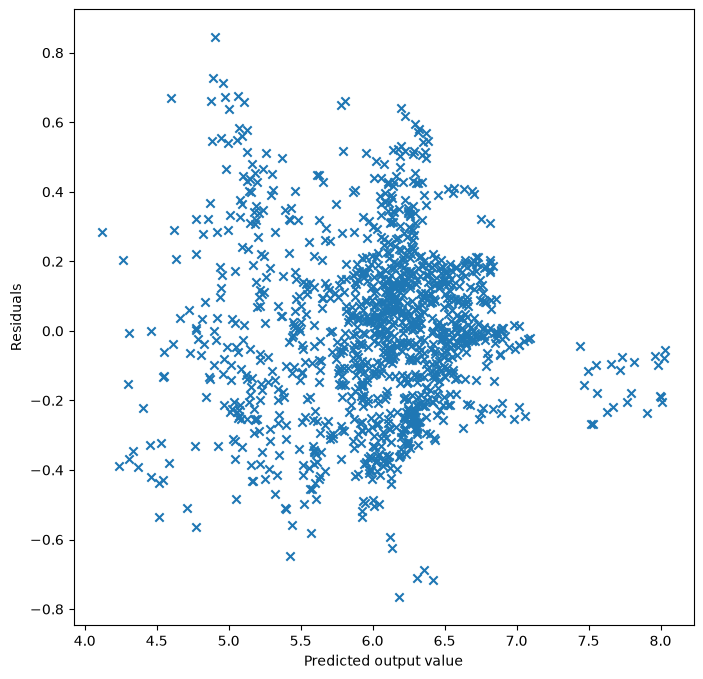

In [9]:
# CODE_CHUNK code_chunk_07
# 1.
plotdata_1e = pd.DataFrame({
    'predicted': lm_pred_1c,
    'residuals': lm_res_1d
})

# 2.
from matplotlib.pyplot import subplots
fig_1e, ax_1e = subplots(figsize = (8,8))
ax_1e.scatter(x='predicted', y='residuals', marker='x', data=plotdata_1e)
ax_1e.set_xlabel("Predicted output value")
ax_1e.set_ylabel("Residuals")

# 3.
rem_patterns1e = "No obvious systematic patterns remain in the residuals." #Write answer as string variable

## Part 2: Least squares regression mechanics
In this more advanced section, you are supposed to create your own algorithms for some standard statistics of a fitted linear regression model from scratch. You are only allowed to use matrix and scalar operations like the NumPy functions

`@, matmul(), transpose(), linalg.solve(), linalg.inv(), subtract(), sum(), mean()`

(or their shortcuts) to manually produce results otherwise produced by `statsmodels`.

### Task 2a) 
Build a function that takes the two-dimensional NumPy arrays `X` and  `y` as its two arguments  and that returns the least squares
estimate $\hat{\beta}$ of the slope coefficients on `X`.

In [11]:
# CODE_CHUNK code_chunk_13
def get_betas(X,y):
    XX = X.T @ X
    Xy = X.T @ y
    beta = np.linalg.solve(XX, Xy)
    return(beta)

get_betas(X_1a, y_1a)

array([-0.02893736,  0.0189599 ,  0.03172034,  0.26524856,  0.46498793,
        3.13920382])

### Task 2b) 
Build a function that computes the model residuals as an object called `res`. Refer to the function written in Task 2a to get an estimate of the slope coefficients.

In [13]:
# CODE_CHUNK code_chunk_14
def get_resid (X,y):
    y_pred = X @ get_betas(X,y)
    res = y - y_pred
    return (res)
get_resid (X_1a, y_1a)

0      -0.085201
1      -0.074076
2      -0.131113
3      -0.130009
4      -0.034476
          ...   
1168    0.540900
1169    0.343179
1170    0.400984
1171    0.319910
1172    0.464562
Length: 1173, dtype: float64

### Task 2c) 
Build a function that computes $R^2$, i.e. the estimated proportion of variance of $y$ that is explained by the model inputs. Refer to the function written in Task 2b to get model residuals. 

In [14]:
# CODE_CHUNK code_chunk_15
def get_R2(X,y):
    e = get_resid (X,y)
    RSS = e.T @ e
    y_dev = y - np.mean(y)
    TSS = y_dev.T @ y_dev
    R2 = 1 - RSS/TSS
    return (R2)

get_R2(X_1a, y_1a)

np.float64(0.8548568798839444)

### Task 2d) 
Next, prepare the inputs that we can feed into our functions. Transform the Pandas data frames `y_1a` and `X_1a` into two-dimensional NumPy arrays and save them as `y_2d` and `X_2d`, respectively.

Then, use your function from Task 2a to learn the coefficient of a linear regression of `y_2d` on `X_2d` and save them as `lm_coef_2d`.

In [15]:
# CODE_CHUNK code_chunk_16
# 1.
y_2d       =  np.asarray (y_1a)
X_2d       =   np.asarray (X_1a)

# 2.
lm_coef_2d = get_betas(X_2d, y_2d)
print(lm_coef_2d)

[-0.02893736  0.0189599   0.03172034  0.26524856  0.46498793  3.13920382]


## Part 3: Logistic regression with `sklearn`

Parts 3 and 4 of this assignment will be based on a dataset on online shopper purchase data which is available on the UC Irvine Machine Learning Repository. A description of all variables is available [here  ](https://www.kaggle.com/henrysue/online-shoppers-intention). Among the 11 variables in the dataset, we will only use the three following:

 - **Revenue**: (TRUE/FALSE) Whether a purchase was made by a visitor to the online shop.
 - **ProductRelated_Duration**: (numerical) Time spent on pages relevant/related to the product in question.
 - **ExitRates**: (numerical) The percentage of visits to the online shop that end with visiting the site of the product at issue.

In this basic part, we are getting some experience with using scikit-learn to learn logistic regressions. In the steps below, we will train a quite small logistic regression model with `Revenue` as output variable and the following inputs (in addition to the intercept):

1. ` ExitRate ` without further transformation
2. The (natural) logarithm of ` ProductRelated_Duration + 1 `
3. The square of the log-transformed ` ProductRelated_Duration `

### Task 3a) 
First, we need to prepare our data. Conduct the following steps:

1. Load the data into python and save it in an object called `shoppers`. The dataset is contained in a comma-separated spreadsheet. Accordingly, you will need to use the `read_csv()` command in Pandas.
2. Use the `columns` method on `shoppers` to change the variable name of `ExitRates` to `ER`. More specifically, you will need to rename a particular column of `shoppers`. 
3. Create a new variable `lPR_Dur` inside `shoppers` that contains the (natural) logarithm of  `ProductRelated_Duration + 1`.

In [16]:
# CODE_CHUNK code_chunk_01
# os.chdir('C:\\Users\\??') # Change working directory if needed

# 1.
shoppers = pd.read_csv("online_shoppers_intention.csv")

# 2.
shoppers = shoppers.rename(columns={'ExitRates': 'ER'})

# 3.
shoppers['lPR_Dur'] = np.log(shoppers['ProductRelated_Duration'] + 1)


### Task 3b)

Technically, we could use the `statsmodels` package to learn logistic regressions. However, the functionality of `statsmodels` addresses applications in classical statistics rather than machine learning. Since we want to use logistic regression as a supervised learning algorithm in order to predict the output of new data points, it is much wiser to switch to scikit-learn (`sklearn`). `sklearn` provides you with simple functions that implement model training, tuning and validation and therefore covers the entire spectrum of standard methods in supervised learning.

Learning a logistic regression with `sklearn` works almost identically as with `statsmodels`. Do it as follows: 

1. Create a  Pandas series `y_3b` that contains the `Revenue` variable from `shoppers`
2. Create a similar data frame `X_3b` whose columns are  ` ER `, ` lPR_Dur ` and the square of `lPR_Dur`.
3. Instantiate a logistic regression model using the `LogisticRegression()` function from the `linear_model` module and save this model specification as `glm_spec_3b`. The function has an argument `penalty`. Set this argument to `None`. Furthermore ensure that an intercept is automatically added to the input variables.
4. Apply the `fit()`-method to `glm_spec_3b` to learn the model and save the learned model as `glm_fit_3b`. Here, specify that the model is learned using with inputs `X_3b` and output `y_3b`.


In [20]:
# CODE_CHUNK code_chunk_02
# 1.
y_3b = shoppers['Revenue']

# 2.
X_3b = shoppers[['ER', 'lPR_Dur']]
X_3b['lPR_Dur2'] = X_3b['lPR_Dur']**2

# 3.
from sklearn.linear_model import LogisticRegression
glm_spec_3b = LogisticRegression(penalty=None)

# 4.
glm_fit_3b  = glm_spec_3b.fit(X_3b, y_3b)

print(glm_fit_3b.coef_)

[[-32.63987528  -0.58940172   0.06451171]]


C:\Users\venia\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Task 3c)
A fundamental principle of machine learning is that we divide the data available to us into different sets which we use for learning, model tuning and algorithm choice. 

`sklearn` makes this very simple for us since its `model_selection`-module contains the `train_test_split()` function. It returns split versions of all objects that you provide as inputs. I prepared a preliminary code chunk below that shows how you need to specify the desired split objects. Complete the code chunk by entering the inputs to `train_test_split()`. More specifically, provide

1. the data objects before splitting in correct order,
2. an argument that allocates 50% of all data points to the training data,
3. an argument that sets the initial state of the random number generator to 3 (we need this to ensure replicability). 


In [21]:
# CODE_CHUNK code_chunk_03
from sklearn.model_selection import train_test_split

X_3b_train, X_3b_test, y_3b_train, y_3b_test = train_test_split(X_3b, y_3b, train_size=0.5, random_state=3)

### Task 3d)
Now, please refit the model from Task 3b using only your training data from Task 3c. Save the resulting learned model as `glm_fit_3d`.

In [22]:
# CODE_CHUNK code_chunk_04
glm_fit_3d =  glm_spec_3b.fit(X_3b_train, y_3b_train)

print(glm_fit_3d.coef_)

[[-32.23959758  -0.68440669   0.07091558]]


C:\Users\venia\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Task 3e) 
Now that we have fitted our model, we want to evaluate its predictive performance on hold-out validation data. We have already created this test data in Task 3c as `y_3b_test` and `X_3b_test.`

Before we can evaluate model performance, we first need to obtain predicted probabilities for purchases on the test data. Use the ` predict_proba() `-method on `glm_fit_3d` to obtain such predicted conditional probabilities from the model fit in Task 3d on the observations in our test set. Save them as `glm_prob_3e`

According to the sklearn documentation, the columns of `glm_prob_3e` contain class probabilities where classes are ordered as they are in `glm_fit_3d.classes_`. Which column index contains the probabilities for class `True`? Write your answer into the string variable `which_column_truepreds_3e`



In [26]:
# CODE_CHUNK code_chunk_05
glm_prob_3e = glm_fit_3d.predict_proba(X_3b_test)
which_column_truepreds_3e = "1"

### Task 3f)
In a next step, we apply a classification rule to map our predicted probabilities into class predictions. Our classification rule is to predict the most likely class.

First, create a new vector ` glm_pred_3f ` which has as many elements as ` glm_prob_3e ` and which consists entirely of the logical statement `False` (without quotation marks!) 

Second, replace `False` in ` glm_pred_3f ` with `True` for all elements where the corresponding predicted probability for category `True` exceeds the threshold used for the classifier mentioned above. You can do this by indexing `glm_pred_3f` using square brackets. Simply write a true-or-false (or logical) statement in the square brackets. For rows where it is true, the value of ` glm_pred_3f ` will be changed.

Please additionally write the true-or-false statement that you use into the string variable ` logical_3f ` for the sake of making assignment evaluation simpler for us.

*Note:* We could even get class predictions by applying the `predict()`-method to `glm_fit_3d`. However, that does not allow us to fully control the classification rule.

In [27]:
### CODE_CHUNK code_chunk_06
# 1.
glm_pred_3f =  np.repeat(False, len(glm_prob_3e))

# 2.
glm_pred_3f[glm_prob_3e[:,1] > 0.5] = True 

print(np.unique(glm_pred_3f, return_counts=True)) # Run this without modification

# 3.
logical_3f = "glm_prob_3e[:,1] > 0.5"

(array([False,  True]), array([6150,   15]))


### Task 3g)
Choose an appropriate error function and write its name in the string variable `chosenerrfun_3g`. Then, use the objects created in the previous tasks of this part to obtain (overall) test error for the logistic regression model fitted in Task 3d.

In [29]:
# CODE_CHUNK code_chunk_07
chosenerrfun_3g = "mean"
testerr_3g      = np.mean(glm_pred_3f != y_3b_test)
print(testerr_3g)

0.15506893755068937


## Part 4: Class-specific prediction errors

This part is more advanced than parts 3 and 5. In classification problems, overall test error may not always be our primary concern. To get a more differentiated picture, confusion matrices and the ROC curve are useful tools. We will get both using the metrics module of Scikit-learn which provides a large number of performance criteria for binary classification. 


### Task 4a)
A basic confusion matrix can easily be obtained using the `confusion_matrix` function of `sklearn.metrics`. This function only requires two inputs:

1. The test outcomes.
2. The predicted class on the test set.

Obtain the confusion matrix and save it as `confumat_4a`.

In [30]:
# CODE_CHUNK code_chunk_08
from sklearn.metrics import confusion_matrix

confumat_4a = confusion_matrix(y_3b_test, glm_pred_3f)
print(confumat_4a)

[[5204   10]
 [ 946    5]]


### Task 4b)
The confusion matrix obtained in the last task is rather rudimentary. For this reason, we are now going to write a function which produces a more luxurious confusion matrix with additional performance measures. 

Below, I prepared a function that takes true outcomes, predicted probabilities for the category of interest and a desired threshold probability for the classification rule as inputs and returns a dictionary object containing the corresponding confusion matrix, TPR, FPR and overall classification error. All that is left for you is the following tasks:

1. Specify the row and column names of the confusion matrix correctly
2. Use the four elements of `cmat` to calculate `FPR`, `TPR` and the classification error `error`.

In [31]:
# CODE_CHUNK code_chunk_09
def  performancemetrics(y_true, y_prob, cutoff):
    # Don't change the 2 rows below
    y_pred       = np.greater(y_prob,cutoff)
    cmat         = confusion_matrix(y_true,y_pred)

    # 1.
    column_names = ["Predicted False", "Predicted True"]
    row_names    = ["Actual False", "Actual True"]

    # 2.
    FPR   =  cmat[0,1] / (cmat[0,0] + cmat[0,1])
    TPR   =  cmat[1,1] / (cmat[1,0] + cmat[1,1])
    error =  (cmat[0,1] + cmat[1,0]) / np.sum(cmat)
    
    # Don't change the two lines below
    cmat         = pd.DataFrame(cmat, columns=column_names, index=row_names)
    allresults = {'confusion_matrix': cmat, 'FPR':FPR, "TPR":TPR, 'classification_error':error}
    return(allresults)

### Task 4c)

Now save as `metrics_4c` the output of `performancemetrics()` with the prediction object of task 4a and a threshold probability of 50% as input. Additionally, answer two questions:

1. Are you satisfied with the overall accuracy with which our model predicts purchases?
2. Is the accuracy with which observed purchases are correctly predicted satisfactory? Assume here that we have considerable interest in predicting actual purchases correctly.

In [32]:
# CODE_CHUNK code_chunk_10

metrics_4c =  performancemetrics(y_3b_test, glm_prob_3e[:,1], 0.5)
print(metrics_4c)
overall_acc_verdict4c      = "Yes"
obs_purchase_acc_verdict4c = "No"


{'confusion_matrix':               Predicted False  Predicted True
Actual False             5204              10
Actual True               946               5, 'FPR': np.float64(0.0019179133103183737), 'TPR': np.float64(0.005257623554153523), 'classification_error': np.float64(0.15506893755068937)}


### Task 4d)

Assume we would like to get a classifier that has relatively balanced class-specific performance. In other words, we want to choose a threshold such that TPR is approximately 1-FPR. In order to see the trade-offs that are available to us, we will look at a ROC curve.

ROC curves can be plotted using the `RocCurveDisplay.from_predictions()` function in the sklearn metrics module. The inputs to this function are 

1. The test outcomes.
2. The predicted probabilities for class 1 on the test set.

Use the code chunk below to plot a ROC curve. Then proceed with the rest of this task in the following text block.

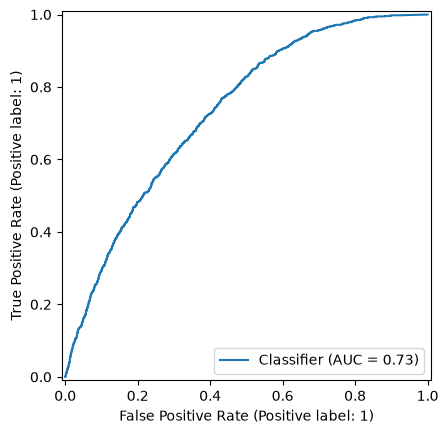

In [33]:
# CODE_CHUNK code_chunk_11
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_3b_test, glm_prob_3e[:,1])

Unfortunately, the plotted ROC curve does not indicate the threshold value leading to a particular point on the curve. Fortunately, the information contained in a ROC curve can be obtained using the `roc_curve()` function in the sklearn metrics module.

The inputs to  `roc_curve()` are true outputs and the predicted probabilities for class 1. Use the corresponding series from Part 3 of this assignment as function inputs and save the result as `roc_fpr_4d`, `roc_tpr_4d` and `roc_thresholds_4d`.

Next, find the the threshold that balances class-specific performance best. You could do that by finding the index at which TPR and (1-FPR) are as close are possible. Then you simply return the value of `roc_thresholds_4d` at this index. State your chosen threshold in the  variable `opt_threshold_4d`. Round to two decimals, if needed.

In [34]:
# CODE_CHUNK code_chunk_12
from sklearn.metrics import roc_curve

# 1.
roc_fpr_4d, roc_tpr_4d, roc_thresholds_4d = roc_curve(y_3b_test, glm_prob_3e[:,1])

# 2.
opt_threshold_4d = roc_thresholds_4d[
    np.argmin(np.abs(roc_tpr_4d - (1 - roc_fpr_4d)))
]

print(opt_threshold_4d)


0.18672966809984096


### Task 4e)
To what extent does our chosen threshold from Task 4d compromise overall accuracy? To find this out, use your `performancemetrics()` function from Task 4b and save the output that you get with the threshold chosen in Task 4d as `metrics_4e`.

Then, use the string variable `is_accuracy_compromised_4e` to discuss whether overall accuracy is notably affected if we switch from a threshold probability of 50% to a value that balances class-specific prediction performance.

In [36]:
# CODE_CHUNK code_chunk_13
metrics_4e = performancemetrics(y_3b_test, glm_prob_3e[:,1], opt_threshold_4d)
print(metrics_4e)

is_accuracy_compromised_4e = "Yes"

{'confusion_matrix':               Predicted False  Predicted True
Actual False             3438            1776
Actual True               324             627, 'FPR': np.float64(0.34062140391254314), 'TPR': np.float64(0.6593059936908517), 'classification_error': np.float64(0.340632603406326)}


## Part 5: Multiclass logistic regression with `sklearn`

We can use the `LogisticRegression` function from `sklearn` to learn models whose output variable has more than two categories. The data we are using to learn a multiclass logistic regression is drug consumption data. Our response variable is usage of drugs (Cocaine, Crack, Ecstasy, and Heroin) and we have three possible responses, "never used", "used more than a year ago", and "used within a year". As explanatory variables we have personality test data, demographic data, and consumption of chocolate, alcohol, and nicotine.

### Task 5a)

Conduct the following steps to prepare your data:

1. Load `drug_train.RDS` using the `read_r()` function in the `pyreadr` package and save it as a data frame `drug_data`. 
2. Extract the variable *drugs.usage* into a Pandas series called `y_5a`
3. Create a Pandas dataframe `X_5a` containing all other variables in `drug_data`.  Note that you will need to transform categorical variables into indicator variables, e.g. using the `get_dummies()` function in Pandas.

In [37]:
# CODE_CHUNK code_chunk_14
# 1.
drug_data = prdr.read_r('drug_train.RDS')
drug_data = drug_data[None]

# 2.
y_5a = drug_data['drugs.usage']

# 3.
X_5a = pd.get_dummies(drug_data.drop(columns=['drugs.usage']))

### Task 5b)

Specify and fit a multinomial logistic regression using `LogisticRegression()`. In the specification, choose no penalty and make sure an intercept is added. Additionally, set the `multi_class` argument to `'multinomial'`. Lastly, increase the number of iterations if this is needed for the learning algorithm to converge.

Save the resulting object as `mlogit_fit_5b`.

In [41]:
# CODE_CHUNK code_chunk_15
mlogit_fit_5b = LogisticRegression(
    penalty=None,
    fit_intercept=True,
    max_iter=1000
).fit(X_5a, y_5a)


C:\Users\venia\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Task 5c)

We now skip the entire data splitting step that we discussed in Part 3. Instead, we say that model `mlogit_fit_5b` is our result of the entire modeling process and it is implemented in practice. We now get new test data for which we obtain output predictions. To prepare this, conduct the following steps:

1. Load *drug_test.RDS* as object `drug_data_test`.
2. Create an input variable matrix `X_5c_test` in the same way as in Task 5a, but using `drug_data_test` instead of `drug_data`.

In [43]:
# CODE_CHUNK code_chunk_16
drug_data_test = prdr.read_r('drug_test.RDS')
drug_data_test = drug_data_test[None]

X_5c_test = pd.get_dummies(
    drug_data_test.drop(columns=['drugs.usage'])
)

### Task 5d)

Get predictions from model `mlogit_fit_5b` for your test data using the `predict_proba()` and `predict()` methods. Save your predictions as `mlogit_prob_5c` and `mlogit_pred_5c`, respectively.

In [44]:
# CODE_CHUNK code_chunk_16
mlogit_prob_5c = mlogit_fit_5b.predict_proba(X_5c_test)
mlogit_pred_5c = mlogit_fit_5b.predict(X_5c_test)

As time passes, you also observe outputs for your first batch of test data. This allows you to evaluate the accuracy of your prediction model during deployment. The variable *drugs.usage* in `drug_data_test` contains these test outputs. Extract them into a vector `ytest_5d`.

Then, use the `confusion_matrix` function in sklearn to get a confusion matrix. Save it as `confumat_5d`.


In [45]:
# CODE_CHUNK code_chunk_18
ytest_5d    = drug_data_test['drugs.usage']
confumat_5d = confusion_matrix(ytest_5d, mlogit_pred_5c)

## Declaration of AI use

If you have used AI in any aspect of your work with this assignment, please indicate this in the string variable below. There is no need to specify further.

In [ ]:
AI = 'yes'